In [13]:
# ==========================================
# PHASE 1 : BUSINESS UNDERSTANDING
# Loan Default Risk Prediction Project
# ==========================================

print("Project Title : Loan Default Risk Prediction")
print("Objective     : Predict whether an applicant is likely to default on a loan.")
print("Business Goal : Help financial institutions reduce credit risk and improve lending decisions.")
print("ML Problem    : Binary Classification")

Project Title : Loan Default Risk Prediction
Objective     : Predict whether an applicant is likely to default on a loan.
Business Goal : Help financial institutions reduce credit risk and improve lending decisions.
ML Problem    : Binary Classification


# Interpretation:
# Banks and lending companies face losses when borrowers fail to repay loans.
# A predictive model helps identify risky applicants before loan approval.
# This improves portfolio quality and reduces defaults.

In [14]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [15]:
# ==========================================
# PHASE 2 : DATA UNDERSTANDING
# Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv(r"C:\Users\milan\Downloads\Loan_Default.csv\Loan_Default.csv")

df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [16]:
# ==========================================
# Basic Dataset Checks
# ==========================================

# Shape of dataset
df.shape

(148670, 34)

In [17]:
# Column Names

df.columns.tolist()

['ID',
 'year',
 'loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'loan_amount',
 'rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'Neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'property_value',
 'construction_type',
 'occupancy_type',
 'Secured_by',
 'total_units',
 'income',
 'credit_type',
 'Credit_Score',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'LTV',
 'Region',
 'Security_Type',
 'Status',
 'dtir1']

In [18]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [19]:
# Missing Values

df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [20]:
# Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [21]:
# Statistical Summary - Numerical Columns

df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [22]:
# Statistical Summary - Categorical Columns

df.describe(include='object')

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
count,145326,148670,147762,148670,148536,148670,148670,148670,148549,148670,...,148670,148670,148670,148670,148670,148670,148470,148470,148670,148670
unique,2,4,2,3,4,2,2,2,2,2,...,2,3,2,4,4,2,7,2,4,2
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,not_neg,not_int,...,sb,pr,home,1U,CIB,CIB,45-54,to_inst,North,direct
freq,135348,42346,124621,113173,55934,142344,148114,127908,133420,141560,...,148637,138201,148637,146480,48152,74392,34720,95814,74722,148637


In [23]:
# ==========================================
# INTERPRETATION CELL
# ==========================================

print("DATA UNDERSTANDING SUMMARY")
print("1. Shape tells number of loan applications and variables.")
print("2. Info() reveals numeric and categorical columns.")
print("3. Missing values indicate preprocessing needs.")
print("4. Duplicate rows can bias model training.")
print("5. Summary statistics help detect outliers or skewed variables.")
print("6. Categorical summary shows frequent categories.")

DATA UNDERSTANDING SUMMARY
1. Shape tells number of loan applications and variables.
2. Info() reveals numeric and categorical columns.
3. Missing values indicate preprocessing needs.
4. Duplicate rows can bias model training.
5. Summary statistics help detect outliers or skewed variables.
6. Categorical summary shows frequent categories.


In [24]:
# ==========================================
# PHASE 3 : DATA CLEANING
# Remove Irrelevant Columns
# ==========================================

df.drop(["ID", "year"], axis=1, inplace=True)

print("Removed ID and year columns.")
print("New Shape:", df.shape)

Removed ID and year columns.
New Shape: (148670, 32)


In [25]:
# Missing Values Percentage

missing = (df.isnull().sum() / len(df)) * 100

missing[missing > 0].sort_values(ascending=False)

Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
age                           0.134526
submission_of_application     0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64

In [26]:
# Interpretation

print("Columns with high missing values need treatment.")
print("Numerical columns -> Median imputation")
print("Categorical columns -> Mode imputation")

Columns with high missing values need treatment.
Numerical columns -> Median imputation
Categorical columns -> Mode imputation


In [27]:
# Separate Numerical and Categorical Columns

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 11
Categorical Columns: 21


In [28]:
# Fill Missing Numerical Values with Median

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Numerical missing values handled.")

Numerical missing values handled.


In [29]:
# Fill Missing Categorical Values with Mode

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical missing values handled.")

Categorical missing values handled.


In [30]:
# Final Missing Values Check

df.isnull().sum().sum()

np.int64(0)

# Interpretation:
# Median imputation was used for numerical variables because several features
# such as income, property_value, and LTV contain extreme values and skewed
# distributions. Median is less sensitive to outliers than mean, making it
# a more robust choice for missing value treatment.

In [32]:
# ==========================================
# PHASE 4 : TARGET ANALYSIS
# Loan Default Distribution
# ==========================================

df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

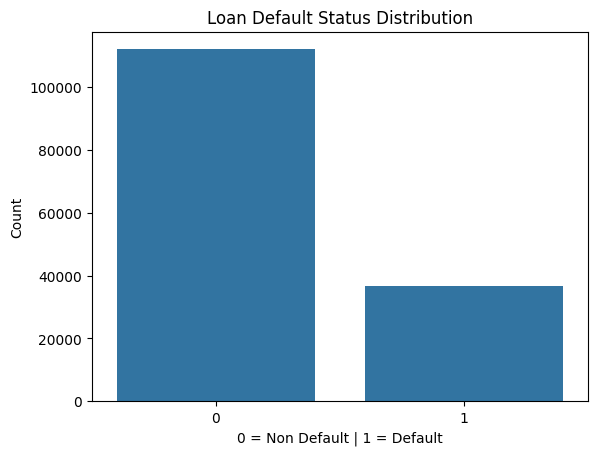

In [33]:
# Visualize Target Variable

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Status")

plt.title("Loan Default Status Distribution")
plt.xlabel("0 = Non Default | 1 = Default")
plt.ylabel("Count")
plt.show()

In [34]:
# Percentage Distribution

df["Status"].value_counts(normalize=True) * 100

Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64

In [35]:
# Interpretation Cell

print("If one class dominates heavily, class imbalance exists.")
print("This can make accuracy misleading.")
print("We may later focus on Precision, Recall, F1, ROC-AUC.")

If one class dominates heavily, class imbalance exists.
This can make accuracy misleading.
We may later focus on Precision, Recall, F1, ROC-AUC.


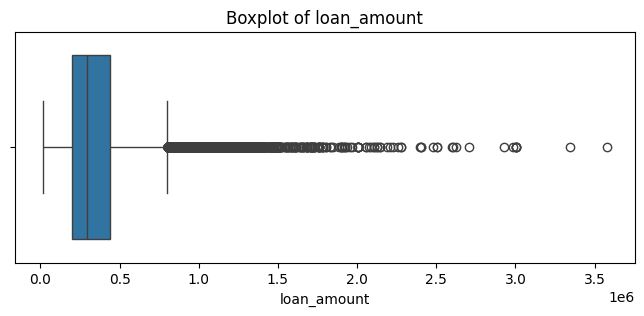

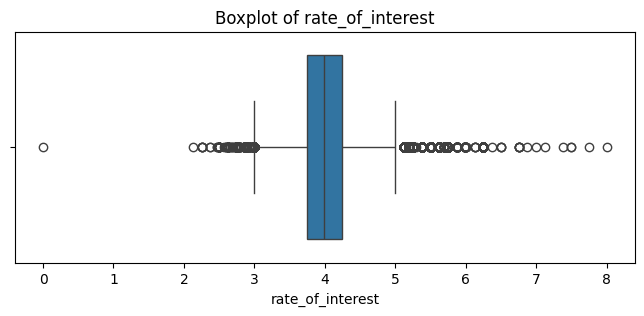

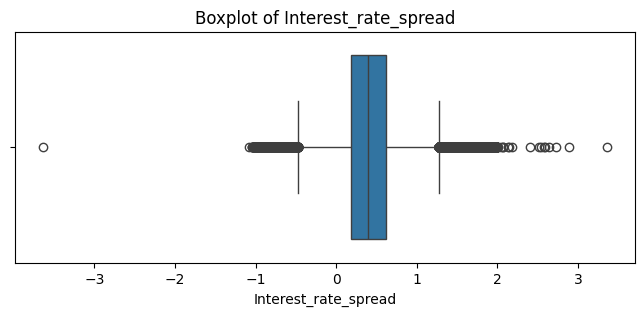

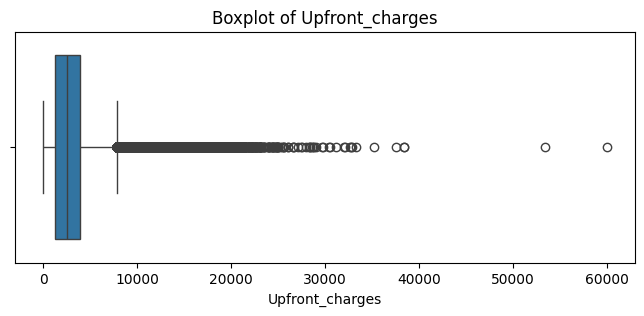

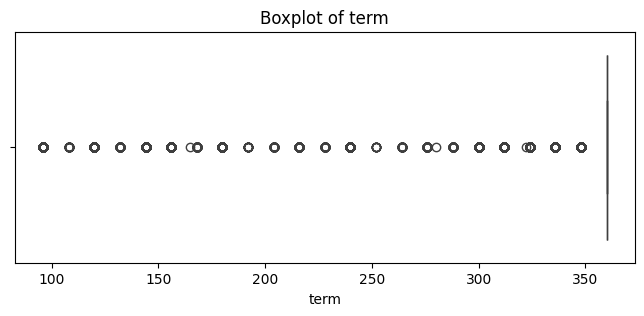

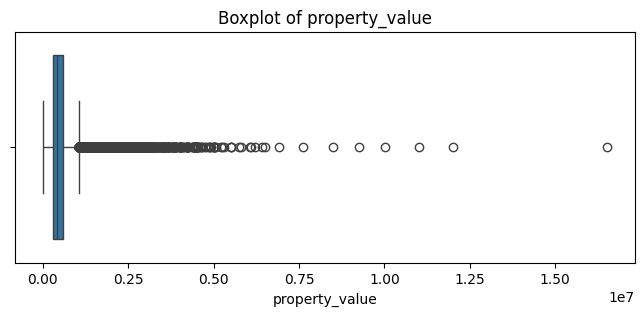

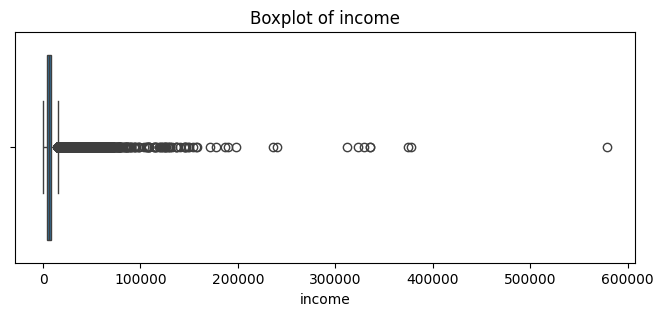

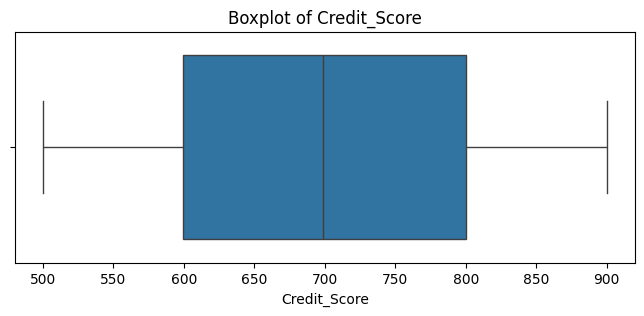

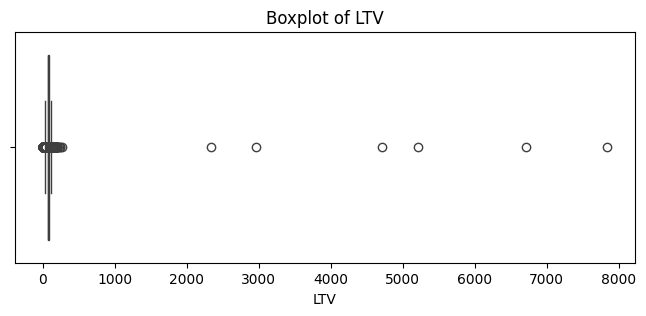

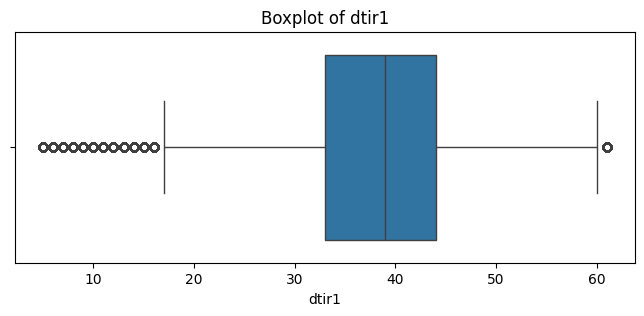

In [36]:
# ==========================================
# PHASE 5 : OUTLIER DETECTION
# Numerical Columns Boxplots
# ==========================================

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != "Status":
        plt.figure(figsize=(8,3))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

In [37]:
# Check Highly Skewed Columns

df[num_cols].skew().sort_values(ascending=False)

LTV                     127.161038
income                   17.844998
property_value            4.872330
Upfront_charges           2.194930
loan_amount               1.666998
Status                    1.176762
rate_of_interest          0.528626
Interest_rate_spread      0.406874
Credit_Score              0.004767
dtir1                    -0.663857
term                     -2.175290
dtype: float64

In [41]:
# ==========================================
# PHASE 6 : OUTLIER TREATMENT (IQR Capping)
# ==========================================


cap_cols = [
    "loan_amount",
    "income",
    "property_value",
    "LTV",
    "Upfront_charges",
    "rate_of_interest",
    "Interest_rate_spread",
    "dtir1"
]

for col in cap_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers capped successfully.")

Outliers capped successfully.


In [44]:
print("Extreme values were capped using IQR method.")
print("This preserves records while reducing distortion in model training.")
print("Especially useful for Logistic Regression and distance-based models.")

Extreme values were capped using IQR method.
This preserves records while reducing distortion in model training.
Especially useful for Logistic Regression and distance-based models.


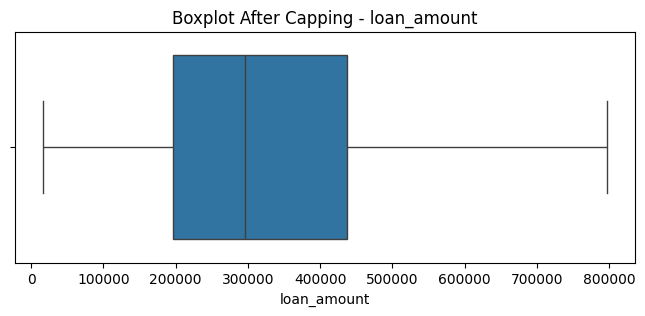

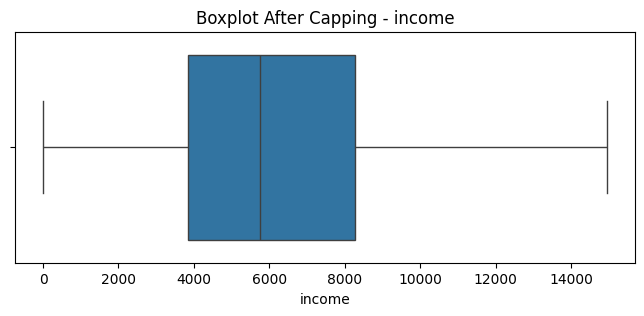

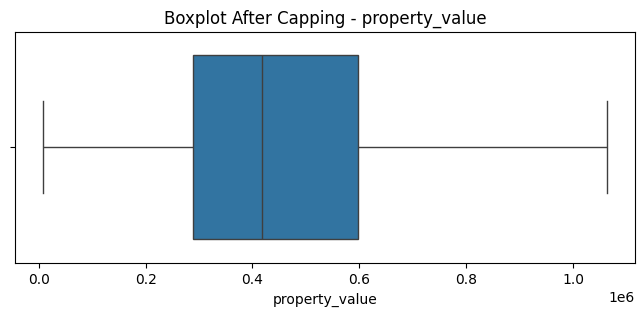

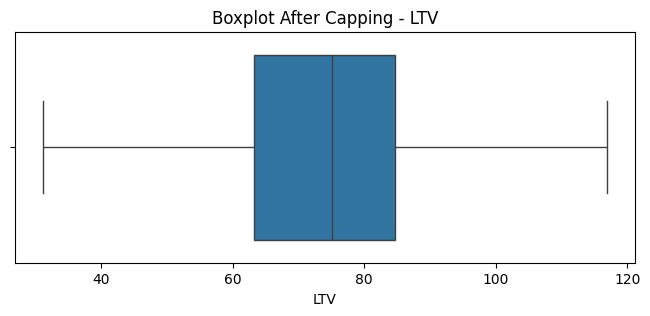

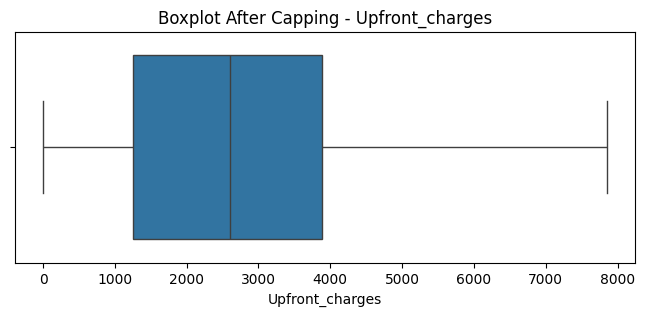

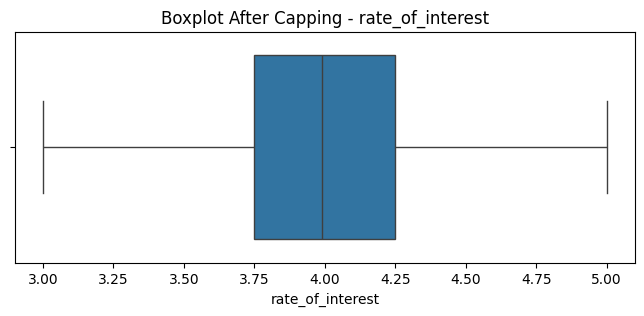

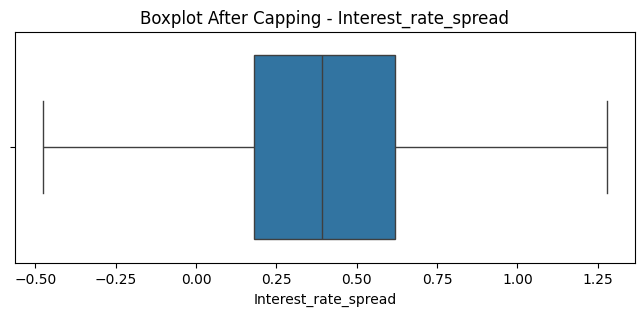

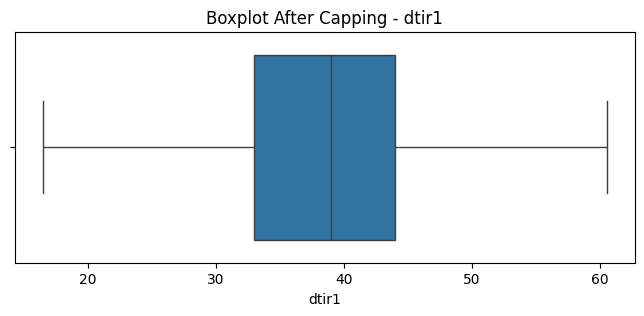

In [46]:
# ==========================================
# VERIFY BOXPLOTS AFTER OUTLIER TREATMENT
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

cap_cols = [
    "loan_amount",
    "income",
    "property_value",
    "LTV",
    "Upfront_charges",
    "rate_of_interest",
    "Interest_rate_spread",
    "dtir1"
]

for col in cap_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot After Capping - {col}")
    
    plt.show()

# Interpretation:
# After capping, extreme points should reduce significantly.
# Some mild outliers may remain naturally, which is acceptable.
# Goal is to reduce extreme distortion, not force perfect normality.

In [49]:
# ==========================================
# PHASE 7 : FEATURE VS TARGET ANALYSIS
# Exploratory Data Analysis (EDA)
# ==========================================

print("Now analyzing which borrower characteristics are linked to default.")

Now analyzing which borrower characteristics are linked to default.


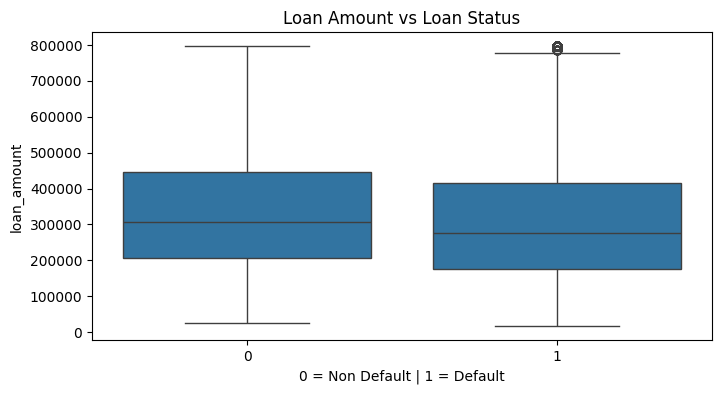

In [50]:
# Loan Amount vs Loan Status

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(data=df, x="Status", y="loan_amount")

plt.title("Loan Amount vs Loan Status")
plt.xlabel("0 = Non Default | 1 = Default")
plt.show()

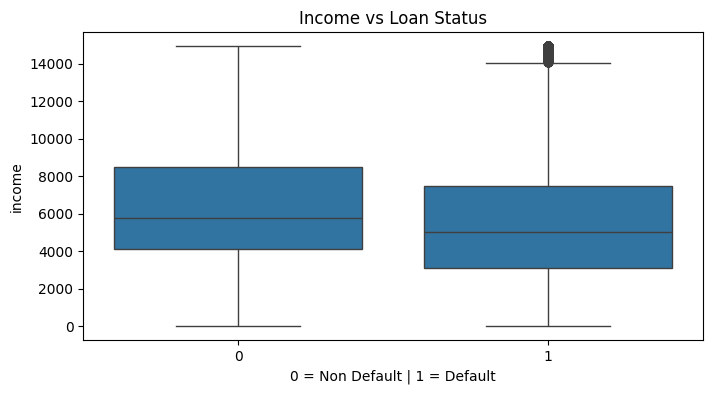

In [51]:
# Income vs Loan Status

plt.figure(figsize=(8,4))

sns.boxplot(data=df, x="Status", y="income")

plt.title("Income vs Loan Status")
plt.xlabel("0 = Non Default | 1 = Default")
plt.show()

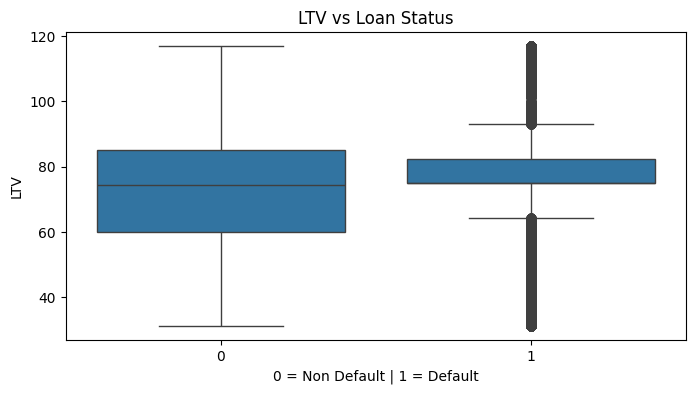

In [52]:
# LTV vs Loan Status

plt.figure(figsize=(8,4))

sns.boxplot(data=df, x="Status", y="LTV")

plt.title("LTV vs Loan Status")
plt.xlabel("0 = Non Default | 1 = Default")
plt.show()

In [53]:
# Interpretation Cell

print("Compare median values between defaulters and non-defaulters.")
print("Lower credit score or higher LTV often indicates higher risk.")

Compare median values between defaulters and non-defaulters.
Lower credit score or higher LTV often indicates higher risk.


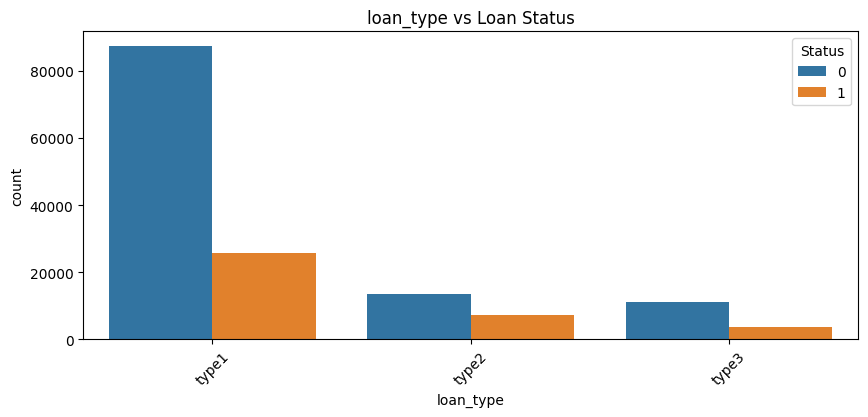

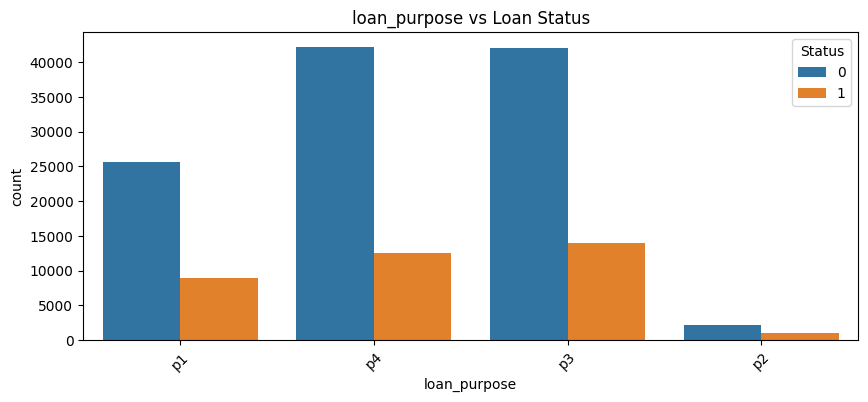

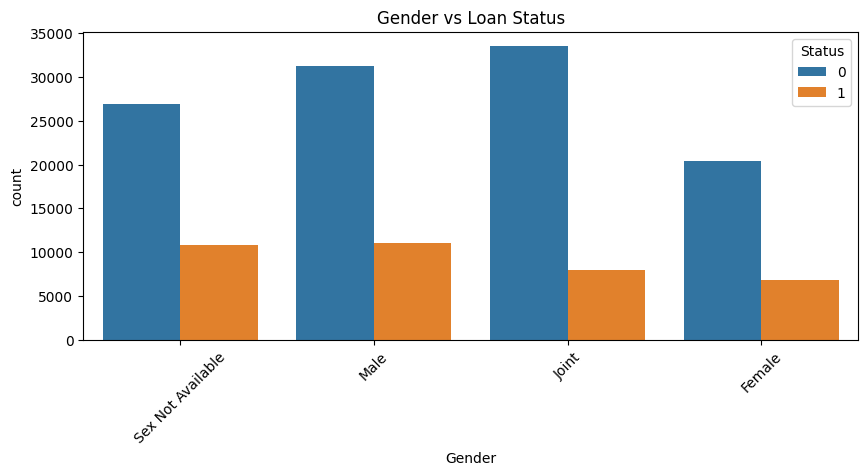

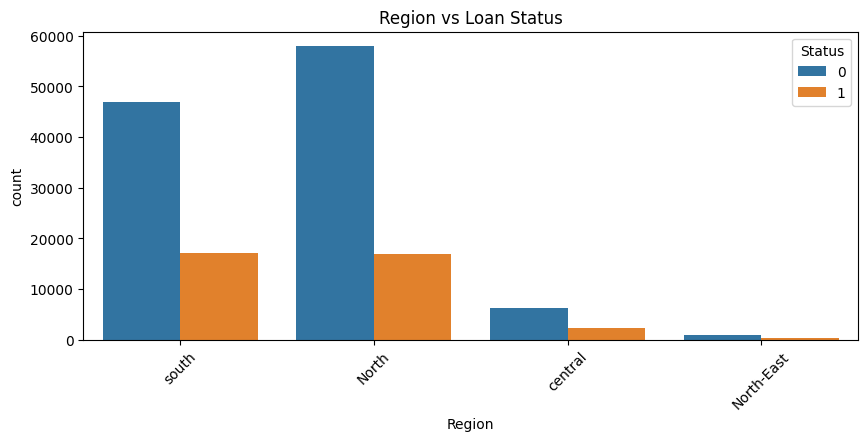

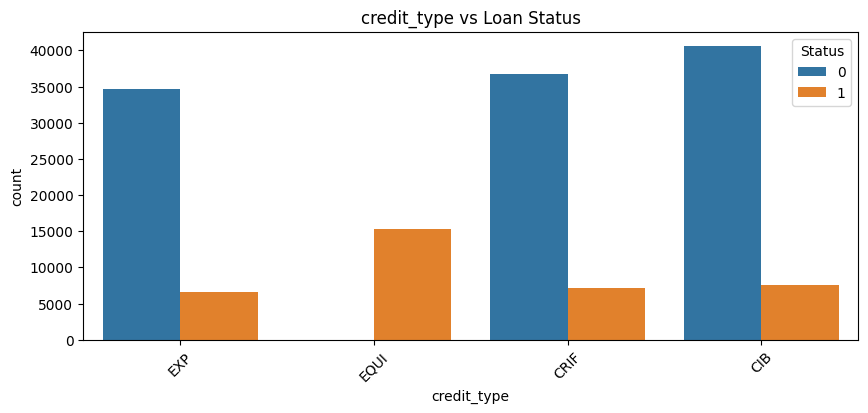

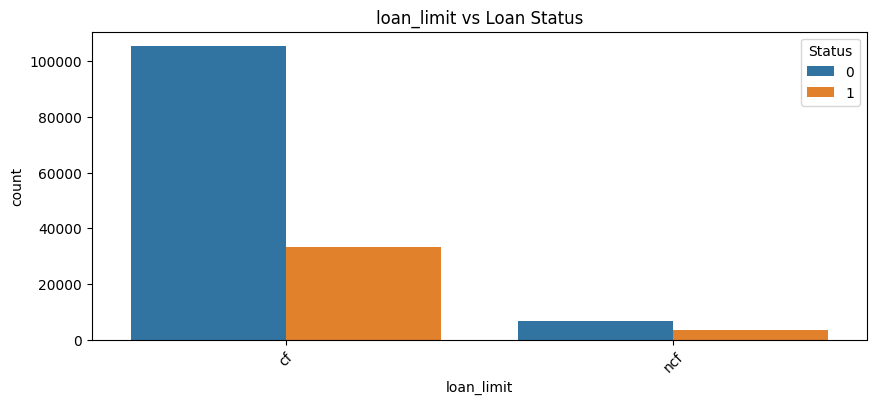

In [54]:
# ==========================================
# CATEGORICAL FEATURES VS TARGET
# ==========================================

cat_features = [
    "loan_type",
    "loan_purpose",
    "Gender",
    "Region",
    "credit_type",
    "loan_limit"
]

for col in cat_features:
    
    plt.figure(figsize=(10,4))
    
    sns.countplot(data=df, x=col, hue="Status")
    
    plt.title(f"{col} vs Loan Status")
    
    plt.xticks(rotation=45)
    
    plt.show()

In [55]:
# Interpretation Cell

print("These visuals reveal borrower segments with higher default counts.")
print("Useful for targeted risk policies.")

These visuals reveal borrower segments with higher default counts.
Useful for targeted risk policies.


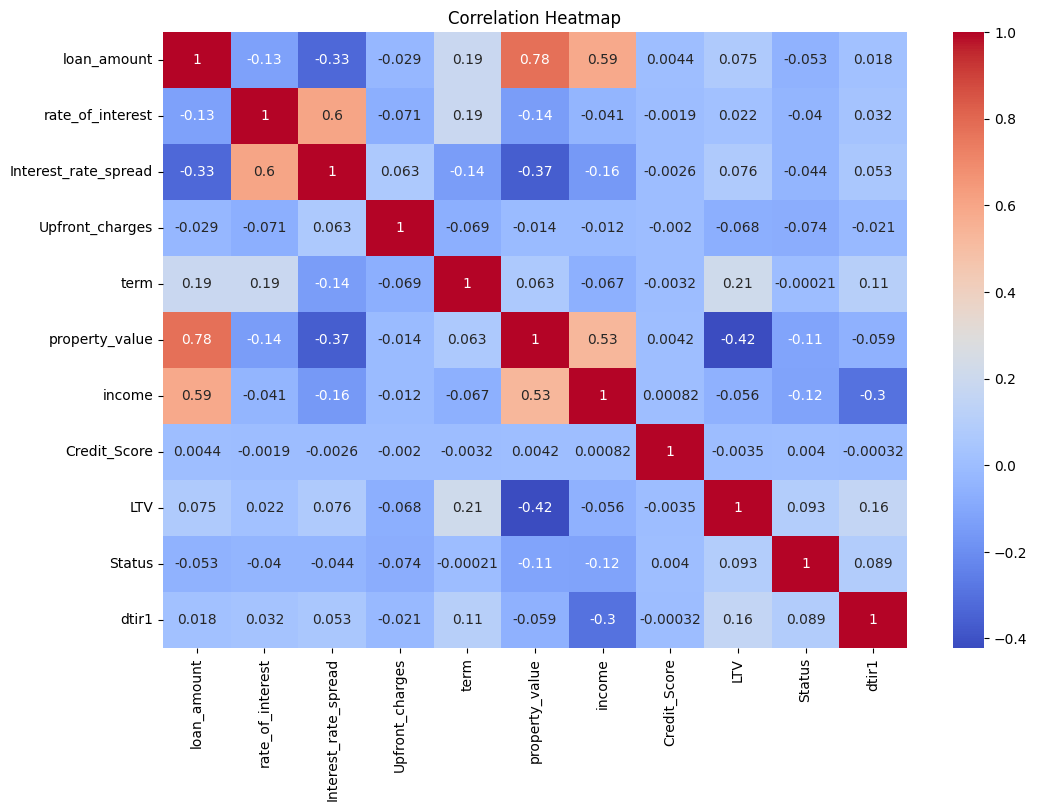

In [84]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(numeric_only=True),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [57]:
# ==========================================
# PHASE 8 : DATA PREPROCESSING FOR MODELING
# Separate Features and Target
# ==========================================

X = df.drop("Status", axis=1)
y = df["Status"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (148670, 31)
Target Shape   : (148670,)


In [58]:
# Check Target Distribution Before Split

y.value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [59]:
# ==========================================
# Encode Categorical Variables
# ==========================================

X = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape :", X.shape)

Encoded Feature Shape : (148670, 48)


In [60]:
# Interpretation

print("Categorical variables converted into numeric format.")
print("Required because ML models cannot train on raw text categories.")

Categorical variables converted into numeric format.
Required because ML models cannot train on raw text categories.


In [61]:
# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (118936, 48)
X_test  : (29734, 48)


In [62]:
# Why Stratify?

print("Stratify preserves default/non-default proportion in train and test sets.")

Stratify preserves default/non-default proportion in train and test sets.


In [63]:
# ==========================================
# Feature Scaling (for LR, KNN, NB)
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [64]:
# Interpretation

print("Scaling helps distance-based and linear models perform better.")
print("Tree models like Random Forest do not require scaling.")

Scaling helps distance-based and linear models perform better.
Tree models like Random Forest do not require scaling.


In [65]:
# Final Ready Message

print("Phase 8 completed: Data prepared for machine learning models.")

Phase 8 completed: Data prepared for machine learning models.


In [67]:
# Interpretation

print("Logistic Regression is a strong baseline model for binary classification.")
print("Useful for probability-based credit risk decisions.")

Logistic Regression is a strong baseline model for binary classification.
Useful for probability-based credit risk decisions.


In [73]:
# Final Model Build Note

print("Phase 9 completed: Five classification models trained successfully.")

Phase 9 completed: Five classification models trained successfully.


In [91]:
# Check columns with one-to-one relation to target

for col in df.columns:
    if col != "Status":
        table = pd.crosstab(df[col], df["Status"])
        if (table == 0).any().any():
            print("\nPotential leakage column:", col)
            print(table.head(20))


Potential leakage column: loan_amount
Status          0     1
loan_amount            
16500           0     3
26500          12    15
36500          55    64
46500         110   102
56500         466   344
66500         505   354
76500        1119   582
86500        1063   542
96500         960   524
106500       2225   985
116500       1661   722
126500       2227   906
136500       2058   822
146500       1993   774
156500       2837  1130
166500       2386   955
176500       2506   913
186500       2530   924
196500       2148   804
206500       3477  1133

Potential leakage column: rate_of_interest
Status               0  1
rate_of_interest         
3.000             3759  0
3.025                3  0
3.050                8  0
3.075                8  0
3.100               13  0
3.125             2010  1
3.150                6  0
3.175               16  0
3.200                4  0
3.225                5  0
3.250             3191  0
3.275                3  0
3.300               12  0

In [92]:
more_suspects = [
    "open_credit",
    "credit_type",
    "co-applicant_credit_type",
    "Interest_rate_spread"
]

df = df.drop(columns=more_suspects)

In [94]:
# Safe leakage column removal

drop_cols = [
    "approv_in_adv",
    "Credit_Worthiness",
    "loan_limit",
    "submission_of_application",
    "construction_type",
    "Secured_by",
    "Security_Type",
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges"
]

df = df.drop(columns=drop_cols, errors="ignore")

print("Leakage columns removed safely.")
print("Current Shape:", df.shape)
print(df.columns.tolist())

Leakage columns removed safely.
Current Shape: (148670, 19)
['Gender', 'loan_type', 'loan_purpose', 'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'occupancy_type', 'total_units', 'income', 'Credit_Score', 'age', 'LTV', 'Region', 'Status', 'dtir1']


In [95]:
# ==========================================
# FINAL PREPROCESSING
# ==========================================

X = df.drop("Status", axis=1)
y = df["Status"]

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("Encoded Shape:", X.shape)

Encoded Shape: (148670, 33)


In [96]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(118936, 33) (29734, 33)


In [97]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [98]:
# ==========================================
# FINAL MODELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

models = {}

# Logistic
log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train_scaled, y_train)
models["Logistic Regression"] = accuracy_score(y_test, log_model.predict(X_test_scaled))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
models["Decision Tree"] = accuracy_score(y_test, dt_model.predict(X_test))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
models["Random Forest"] = accuracy_score(y_test, rf_model.predict(X_test))

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
models["KNN"] = accuracy_score(y_test, knn_model.predict(X_test_scaled))

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
models["Naive Bayes"] = accuracy_score(y_test, nb_model.predict(X_test_scaled))

results_df = pd.DataFrame(models.items(), columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.891807
1,Decision Tree,0.821013
3,KNN,0.797908
0,Logistic Regression,0.774568
4,Naive Bayes,0.744770


In [99]:
# ==========================================
# PREDICTIONS FOR FINAL METRICS
# ==========================================

log_pred = log_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
knn_pred = knn_model.predict(X_test_scaled)
nb_pred = nb_model.predict(X_test_scaled)

In [100]:
# Probability Scores

log_prob = log_model.predict_proba(X_test_scaled)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]
knn_prob = knn_model.predict_proba(X_test_scaled)[:,1]
nb_prob = nb_model.predict_proba(X_test_scaled)[:,1]

In [101]:
# Full Metrics Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = []

models_eval = {
    "Logistic Regression": (log_pred, log_prob),
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "KNN": (knn_pred, knn_prob),
    "Naive Bayes": (nb_pred, nb_prob)
}

for name, (pred, prob) in models_eval.items():
    
    comparison.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

metrics_df = pd.DataFrame(comparison, columns=[
    "Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"
])

metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7746,0.6761,0.1638,0.2636,0.6889
1,Decision Tree,0.8210,0.6294,0.6658,0.6471,0.7688
2,Random Forest,0.8918,0.9316,0.6055,0.7339,0.8784
3,KNN,0.7979,0.6490,0.3919,0.4887,0.7469
4,Naive Bayes,0.7448,0.4693,0.2725,0.3448,0.6797


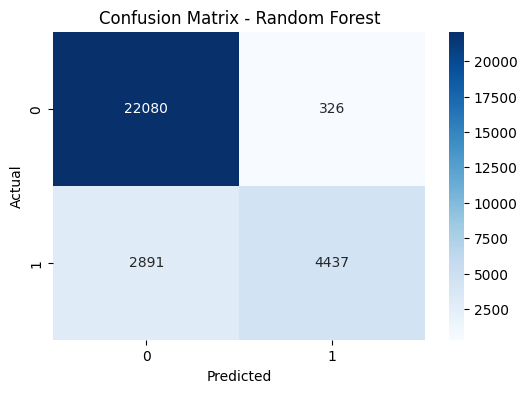

In [102]:
# ==========================================
# FINAL PHASE 1 : Confusion Matrix
# Best Model = Random Forest
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [103]:
# Interpretation

print("True Negatives  : Correctly predicted non-defaulters")
print("True Positives  : Correctly predicted defaulters")
print("False Positives : Safe applicants flagged risky")
print("False Negatives : Risky applicants missed")

True Negatives  : Correctly predicted non-defaulters
True Positives  : Correctly predicted defaulters
False Positives : Safe applicants flagged risky
False Negatives : Risky applicants missed


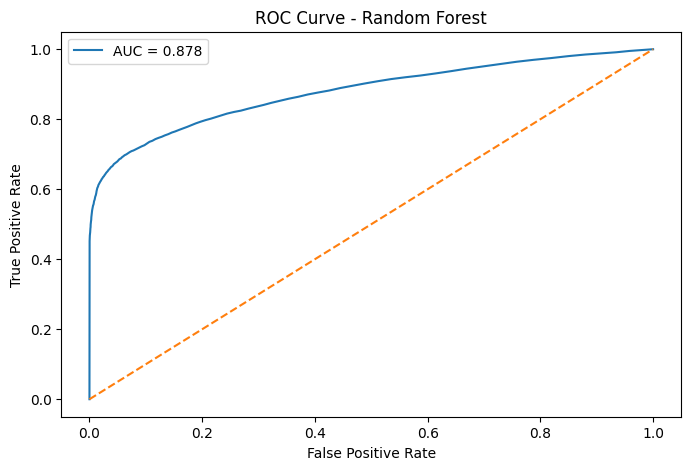

In [104]:
# ==========================================
# FINAL PHASE 2 : ROC Curve
# ==========================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [105]:
# Interpretation

print("Higher AUC means better ability to separate defaulters vs non-defaulters.")

Higher AUC means better ability to separate defaulters vs non-defaulters.


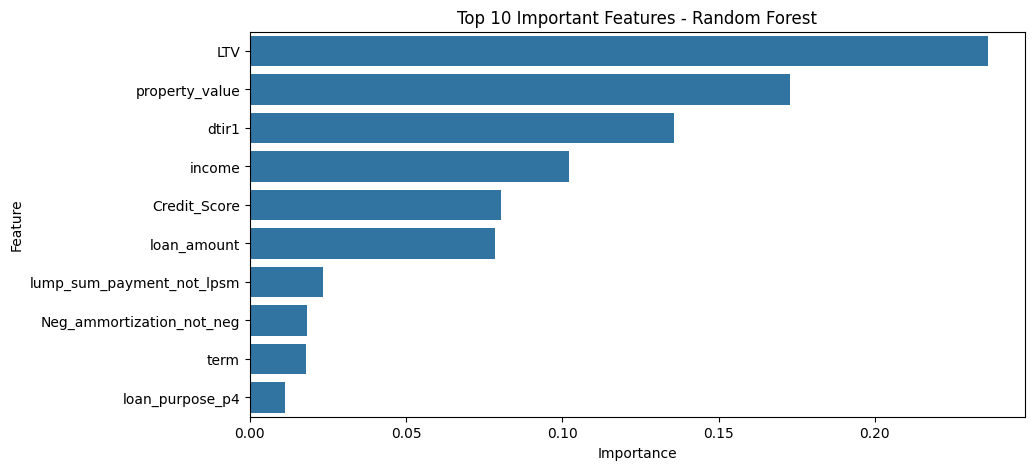

In [106]:
# ==========================================
# FINAL PHASE 3 : Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [107]:
# Interpretation

print("These variables contribute most to default prediction.")
print("Useful for credit policy and underwriting decisions.")

These variables contribute most to default prediction.
Useful for credit policy and underwriting decisions.


In [108]:
# ==========================================
# FINAL PHASE 4 : Business Insights
# ==========================================

print("KEY INSIGHTS")
print("1. Credit score and LTV strongly influence default risk.")
print("2. Borrowers with weaker financial profiles show higher risk.")
print("3. Random Forest provided the best predictive performance.")
print("4. ML models can improve loan approval quality.")

KEY INSIGHTS
1. Credit score and LTV strongly influence default risk.
2. Borrowers with weaker financial profiles show higher risk.
3. Random Forest provided the best predictive performance.
4. ML models can improve loan approval quality.


In [110]:
# ==========================================
# FINAL PHASE 5 : Completion Message
# ==========================================

print("===================================")
print(" LOAN DEFAULT PROJECT COMPLETED ")
print("===================================")

print("Best Model : Random Forest")
print("Accuracy   : 89.18%")
print("ROC-AUC    : 0.878")

 LOAN DEFAULT PROJECT COMPLETED 
Best Model : Random Forest
Accuracy   : 89.18%
ROC-AUC    : 0.878
